
# $h_k(t)$ exacto (semi-analítico) — potencial isócrono

Calcula los modos de Fourier de mezcla de fase $h_k(t)$ de forma **exacta**
(cuadratura numérica de alta resolución sobre las variables ángulo-acción,
sin partículas ni ruido de discretización), para compararlos contra los
$h_k(t)$ que salen de una corrida real de `vlasov-poisson_PIC`/
`VlasovPoisson_PIC_sp`.

**Motivación**: en las corridas PIC (tanto reconstruidas como los datos
originales del artículo), $h_k$ para $k>0$ no decae hasta el piso de ruido
que predice la teoría — se estabiliza varios órdenes de magnitud por
arriba de lo esperado. Este notebook calcula la referencia "verdadera"
(sin ese artefacto) para poder cuantificar la brecha con precisión, en vez
de compararla a ojo.

## Ecuaciones (ver `main.md`, Secc. 3-4, y `BUGS_TODO.md`/
`h0_normalization_check.md` de esta sesión)

Con el potencial isócrono adimensional ($G=M_{iso}=m=b=1$) y momento
angular fijo $L_0$, la frecuencia radial es
$$\omega(J) = \frac{1}{\left[J+\tfrac12\left(L_0+\sqrt{L_0^2+4}\right)\right]^3}.$$

La distribución inicial (Ec. DF$_{aa}$ del artículo) es un pulso en
variables ángulo-acción:
$$\mathcal F_0(Q,J) = A_0\, e^{-\sin^2(Q/2)/\sigma_Q^2}\, e^{-(J-J_0)^2/\sigma_J^2}\, J^2,$$
y su coeficiente de Fourier en $Q$ (a $J$ fijo) es
$$\hat{\mathcal F}_k(J) = \frac{1}{2\pi}\int_0^{2\pi} \mathcal F_0(Q,J)\, e^{-ikQ}\, dQ
= A_0\, e^{-(J-J_0)^2/\sigma_J^2} J^2 \cdot \underbrace{\frac{1}{2\pi}\int_0^{2\pi} e^{-\sin^2(Q/2)/\sigma_Q^2}\cos(kQ)\, dQ}_{\text{mismo para } \Phi}.$$

(La parte imaginaria se cancela por simetría — $\mathrm{Re}$ es par y
$\mathrm{Im}$ impar respecto a $Q=\pi$ — así que no hace falta calcularla.)

La función de prueba $\Phi$ tiene la misma forma con $A_0=1$ y sus propios
parámetros $(J_0^\Phi,\sigma_Q^\Phi,\sigma_J^\Phi)$. El modo de mezcla,
**Ec. 44 del artículo** (reducida vía $\mathcal F(r,p_r,L)=\mathcal
F_0(r,p_r)\,\delta(L-L_0)$, ver la derivación completa en
`h0_normalization_check.md` §3 y §9-10 de esta sesión), es
$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \int_0^\infty \hat{\mathcal F}_k(J)\,
\hat\Phi_k(J)^*\, e^{-ik\,\omega(J)\,t}\, dJ.$$

El factor $8\pi^2 L_0$ es exactamente el que faltaba en el código
Fortran (`analysish.f90`) y que agregamos esta sesión — acá se incluye
desde el principio.


In [1]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "



## 1. Parámetros físicos

Los valores por defecto reproducen el test de validación del artículo
(Tabla 1/2, Fig. 3): $L_0=2$, $\sigma_Q=\sigma_J=0.1$, $J_3^{(0)}=0$,
masa $a_0 = 10^{-4}\,M_{iso}$.

La función de prueba $\Phi$ por defecto es igual a $\mathcal F_0$ (con
$A_0=1$) — el caso que usa la Tabla 1. Para reproducir el caso con
$\Phi_2$ de la Tabla 3, cambiá `J0_phi`, `sQ_phi`, `sJ_phi` más abajo.


In [2]:

# --- Distribucion inicial F0 (Ec. DF_aa) ---
L0   = 2.0     # momento angular fijo
J0_F = 0.0     # J3^(0)
sQ_F = 0.1     # sigma_Q
sJ_F = 0.1     # sigma_J
a0_target = 1.0e-4   # masa objetivo, en unidades de M_iso

# --- Funcion de prueba Phi (por defecto: igual a F0, A0=1) ---
J0_phi = 0.0
sQ_phi = 0.1
sJ_phi = 0.1

# --- Resolucion de las cuadraturas ---
nQ   = 4000     # subintervalos de Simpson en Q, sobre [0,2pi]
Jmax = 3.0      # dominio de integracion en J: [0, Jmax]
nJ   = 8000     # subintervalos de Simpson en J

modes = [0, 1, 2, 3, 4]   # que k's calcular



## 2. Funciones auxiliares

Cuadratura de Simpson manual (no usa `scipy.integrate` — evita
problemas de compatibilidad de versión numpy/scipy en algunos entornos;
con `nQ`/`nJ` de varios miles la precisión es más que suficiente).


In [3]:

def simpson(y, x):
    '''Cuadratura de Simpson compuesta, x uniforme, len(x) impar (n par).'''
    n = len(x) - 1
    assert n % 2 == 0, "se necesita un numero par de subintervalos"
    h = (x[-1] - x[0]) / n
    return (y[0] + y[-1] + 4*np.sum(y[1:-1:2]) + 2*np.sum(y[2:-2:2])) * h / 3.0


def omega(J, L=L0):
    '''Frecuencia radial del potencial isocrono adimensional.'''
    return 1.0 / (J + 0.5*(L + np.sqrt(L**2 + 4.0)))**3


def Fhat_k_over_A0(Js, k, J0, sQ, sJ):
    '''Coeficiente de Fourier en Q (real), con amplitud A0=1:
    (1/2pi) * Simpson[ exp(-sin(Q/2)^2/sQ^2) * cos(kQ) dQ, 0..2pi ]
    * exp(-(J-J0)^2/sJ^2) * J^2 , evaluado en el arreglo Js.
    '''
    Qs = np.linspace(0.0, 2*np.pi, nQ + 1)
    g = np.exp(-np.sin(0.5*Qs)**2 / sQ**2)
    Qint = simpson(g * np.cos(k*Qs), Qs) / (2*np.pi)
    return Qint * np.exp(-(Js - J0)**2 / sJ**2) * Js**2



## 3. Normalización de masa

$a_0$ (fracción de $M_{iso}$) fija $A_0$ vía
$M_{gas} = 8\pi^2 L_0 \int\!\!\int \mathcal F_0(Q,J)\, dQ\, dJ
= 8\pi^2 L_0 \cdot 2\pi \int \hat{\mathcal F}_0(J)\, dJ$
(con $k=0$: la integral en $Q$ da el promedio angular).


In [4]:

Js_mass = np.linspace(0.0, Jmax, nJ + 1)
IJ0 = simpson(Fhat_k_over_A0(Js_mass, 0, J0_F, sQ_F, sJ_F), Js_mass)
mass_per_A0 = 8*np.pi**2 * L0 * 2*np.pi * IJ0

A0 = a0_target / mass_per_A0
print(f"masa por unidad de A0 = {mass_per_A0:.6e}")
print(f"A0 (para masa = {a0_target:g} M_iso) = {A0:.6e}")


masa por unidad de A0 = 2.486775e-02
A0 (para masa = 0.0001 M_iso) = 4.021273e-03



## 4. Cálculo de $h_k(t)$

$$h_k(t) = 8\pi^2 L_0 \cdot 2\pi \cdot A_0 \int_0^{J_{max}}
\hat{\mathcal F}_k^{(A_0=1)}(J)\, \hat\Phi_k(J)\, e^{-ik\,\omega(J)\,t}\, dJ$$

($\hat\Phi_k$ ya tiene $A_0=1$ por definición de función de prueba.)


In [5]:

Js = np.linspace(0.0, Jmax, nJ + 1)
om = omega(Js)

FACTOR = 8*np.pi**2 * L0 * 2*np.pi * A0

# Fhat_k y Phihat_k no dependen de t: calcularlos una sola vez por modo.
Fhat  = {k: Fhat_k_over_A0(Js, k, J0_F,   sQ_F,   sJ_F)   for k in modes}
Phhat = {k: Fhat_k_over_A0(Js, k, J0_phi, sQ_phi, sJ_phi) for k in modes}

def hk_exact(k, t):
    '''h_k(t) exacto (complejo). t puede ser escalar o arreglo.'''
    t = np.atleast_1d(t).astype(float)
    out = np.empty(t.shape, dtype=complex)
    for i, ti in enumerate(t):
        integrand = Fhat[k] * Phhat[k] * np.exp(-1j*k*om*ti)
        re = simpson(integrand.real, Js)
        im = simpson(integrand.imag, Js)
        out[i] = FACTOR * (re + 1j*im)
    return out if out.size > 1 else out[0]



## 5. Evaluar en una grilla de tiempo y graficar cada modo


In [6]:

t_array = np.linspace(0.0, 10000.0, 400)

hk_t = {k: np.abs(hk_exact(k, t_array)) for k in modes}

print(f"h_0 (constante en t, teoria de mezcla): {hk_t[0][0]:.6e}")
for k in modes[1:]:
    print(f"h_{k}(t=0) = {hk_t[k][0]:.3e}   h_{k}(t=10000) = {hk_t[k][-1]:.3e}")


h_0 (constante en t, teoria de mezcla): 1.499817e-08
h_1(t=0) = 1.470e-08   h_1(t=10000) = 5.631e-16
h_2(t=0) = 1.383e-08   h_2(t=10000) = 1.648e-17
h_3(t=0) = 1.251e-08   h_3(t=10000) = 1.971e-18
h_4(t=0) = 1.086e-08   h_4(t=10000) = 4.303e-19


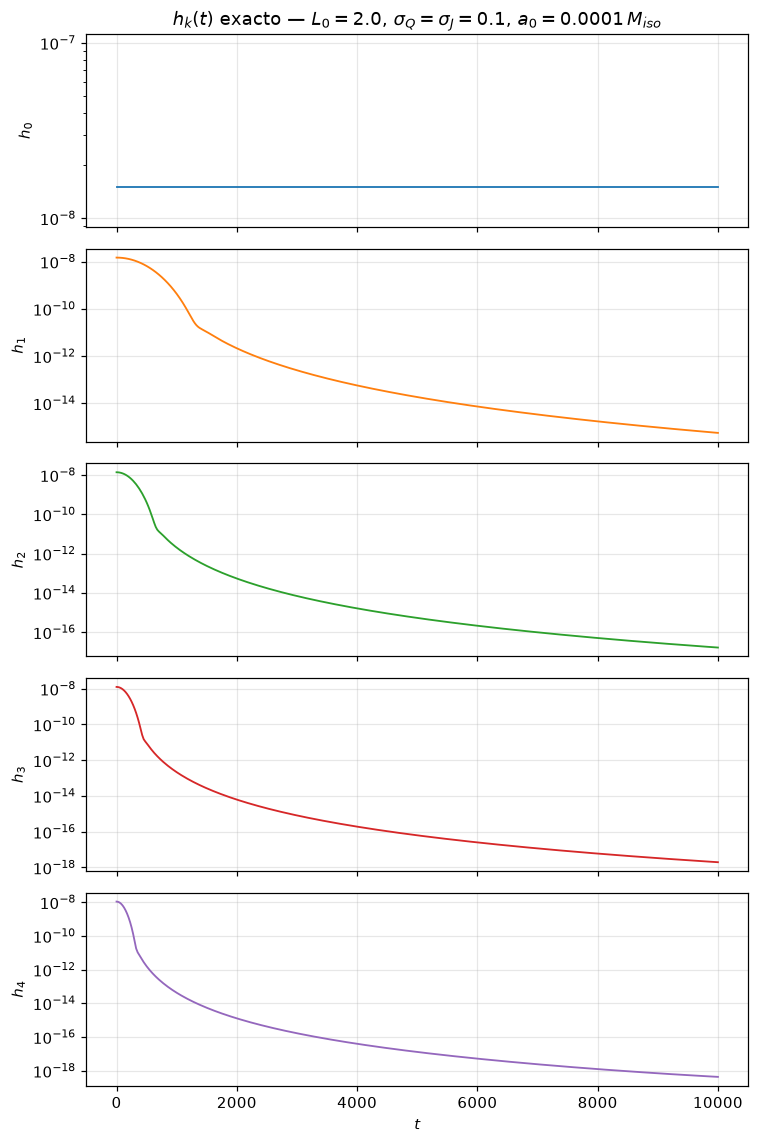

In [7]:

fig, axes = plt.subplots(len(modes), 1, figsize=(7, 2.1*len(modes)), sharex=True)
for ax, k in zip(axes, modes):
    ax.plot(t_array, hk_t[k], lw=1.2, color=f"C{k}")
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("$t$")
axes[0].set_title(f"$h_k(t)$ exacto — $L_0={L0}$, $\\sigma_Q=\\sigma_J={sQ_F}$, $a_0={a0_target:g}\\,M_{{iso}}$")
fig.tight_layout()
fig.savefig("hk_exact_modes.png", dpi=140)
plt.show()


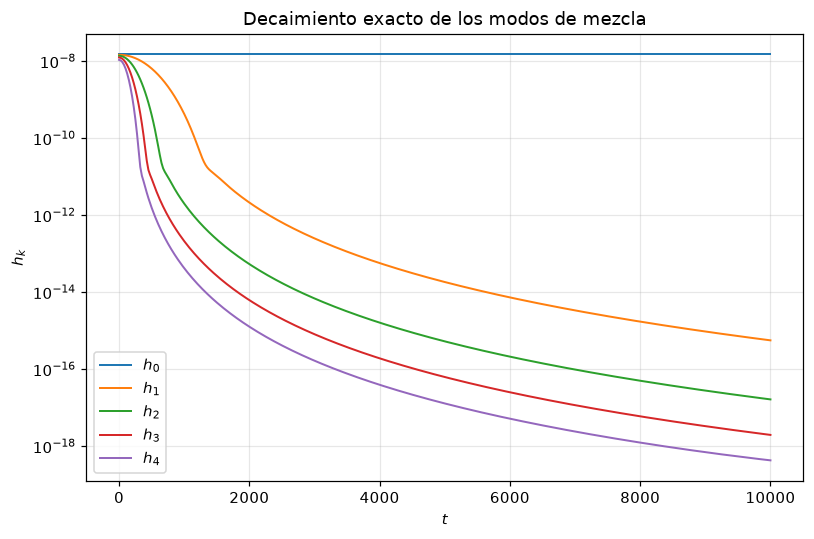

In [8]:

# Mismos datos, superpuestos en un solo eje (estilo Fig. 3 del articulo)
fig, ax = plt.subplots(figsize=(7.5, 5))
for k in modes:
    ax.plot(t_array, hk_t[k], lw=1.3, label=f"$h_{k}$")
ax.set_yscale("log")
ax.set_xlabel("$t$")
ax.set_ylabel("$h_k$")
ax.set_title("Decaimiento exacto de los modos de mezcla")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("hk_exact_overlay.png", dpi=140)
plt.show()



## 6. Convergencia con $N_c$: comparar contra corridas PIC reales

Corridas con los parámetros exactos de la Tabla 1 (potencial isócrono,
sin autogravedad, $L_0=2$, $\sigma_Q=\sigma_J=0.1$, $a_0=10^{-4}M_{iso}$,
`cutoff=0.01`, $N_t=400000$ hasta $t=10000$), a dos resoluciones:

| | $N_c$ nominal | partículas reales (tras el corte) |
|---|---|---|
| `hk1_N1e3.tl` | $10^3$ | 1001 |
| `hk1_N1e4.tl` | $10^4$ | 10072 |

Cada archivo tiene columnas `t h0 h1 h2 h3 h4`, ya con el factor
$8\pi^2L_0$ (código posterior al fix de esta sesión).


In [9]:

import os

data_dir = "data"
sims = {}
for label, fname in [("$N_c\\sim10^3$", "hk1_N1e3.tl"), ("$N_c\\sim10^4$", "hk1_N1e4.tl")]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")

for label, data in sims.items():
    print(f"{label}: {data.shape[0]} filas, t de {data[0,0]:.0f} a {data[-1,0]:.0f}")


$N_c\sim10^3$: 4001 filas, t de 0 a 10000
$N_c\sim10^4$: 4001 filas, t de 0 a 10000



### Cada modo: exacto vs. las dos resoluciones

A mayor $N_c$, la curva simulada debería seguir a la exacta durante más
tiempo antes de "pegarse" a su propio piso de ruido de discretización
(finito número de partículas) -- la resolución no cambia *dónde* decae
la física, cambia *cuánto* tiempo se puede seguir esa caída antes de
que el ruido la tape.


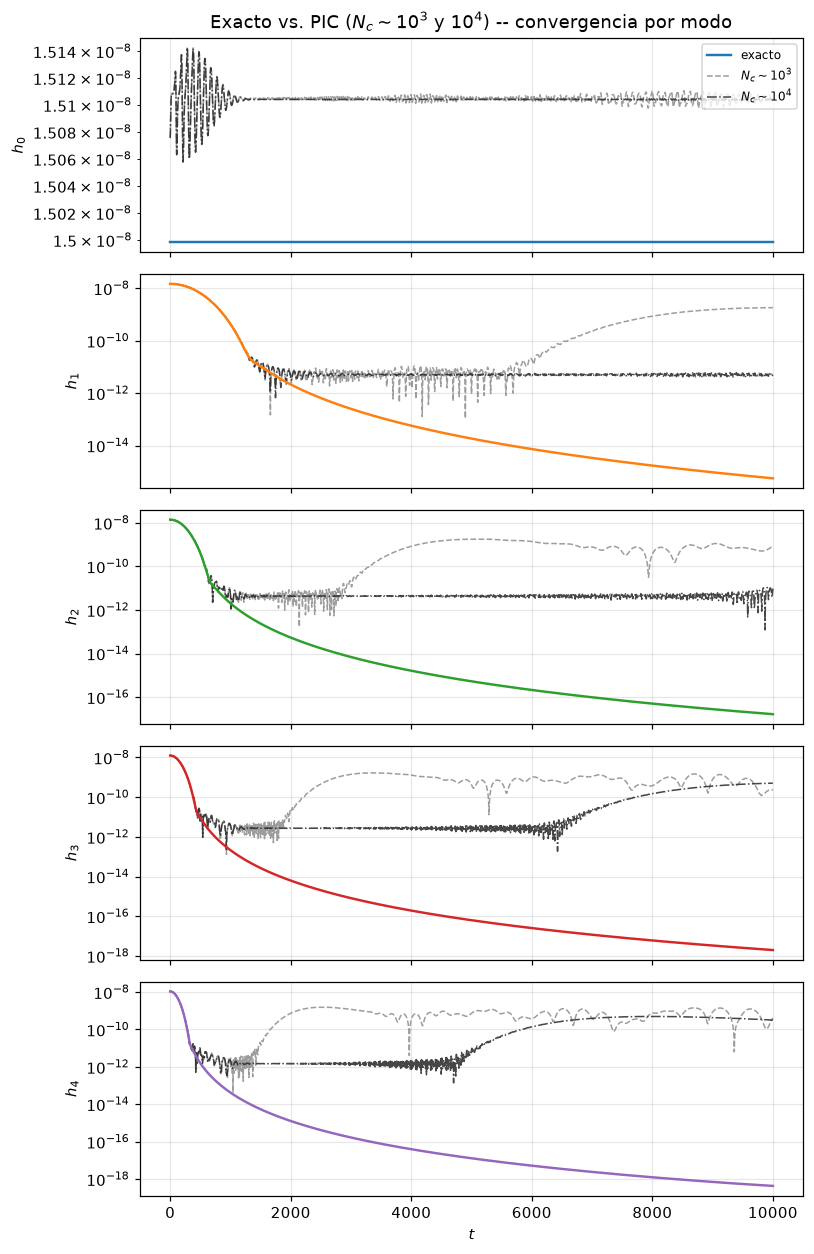

In [10]:

sim_colors = {"$N_c\\sim10^3$": "0.55", "$N_c\\sim10^4$": "0.15"}
sim_styles = {"$N_c\\sim10^3$": "--", "$N_c\\sim10^4$": "-."}

fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
for ax, k in zip(axes, modes):
    ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
    for label, data in sims.items():
        ax.plot(data[:, 0], data[:, k+1], lw=1.0, color=sim_colors[label],
                 ls=sim_styles[label], alpha=0.85, label=label)
    ax.set_yscale("log")
    ax.set_ylabel(f"$h_{k}$")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8, loc="upper right")
axes[-1].set_xlabel("$t$")
axes[0].set_title("Exacto vs. PIC ($N_c\\sim10^3$ y $10^4$) -- convergencia por modo")
fig.tight_layout()
fig.savefig("hk_convergence.png", dpi=140)
plt.show()



### Piso de ruido: valor asintótico medido vs. exacto en $t=10000$

Tabla resumen -- promedio y desviación estándar en $t\in[8000,10000]$
para cada corrida, contra el valor exacto en $t=10000$.


In [11]:

mask_exact = t_array >= 8000
print(f"{'modo':<6}{'exacto (t=10000)':>20}", end="")
for label in sims:
    print(f"{label + ' media':>22}{label + ' sigma':>18}", end="")
print()

for k in modes:
    row = f"h{k:<5}{hk_t[k][-1]:>20.3e}"
    for label, data in sims.items():
        m = data[:, 0] >= 8000
        vals = data[m, k+1]
        row += f"{vals.mean():>22.3e}{vals.std():>18.3e}"
    print(row)


modo      exacto (t=10000)   $N_c\sim10^3$ media$N_c\sim10^3$ sigma   $N_c\sim10^4$ media$N_c\sim10^4$ sigma
h0               1.500e-08             1.510e-08         3.241e-12             1.510e-08         3.044e-13
h1               5.631e-16             1.464e-09         2.912e-10             5.071e-12         4.471e-13
h2               1.648e-17             6.990e-10         2.076e-10             4.737e-12         1.615e-12
h3               1.971e-18             7.282e-10         3.862e-10             3.497e-10         1.088e-10
h4               4.303e-19             8.192e-10         3.920e-10             4.260e-10         5.515e-11



## 7. ¿Ayuda el jitter sub-celda (Weyl/Kronecker)?

Experimento (sin commitear, ver `src/initial_data.f90` en
`vlasov-poisson_PIC`): en vez de poner cada partícula exactamente en el
centro de su celda $(r,p)$, se la desplaza con un offset determinístico
de baja discrepancia (secuencia de Weyl, razón áurea / $\sqrt2-1$) del
tamaño de la propia celda. La hipótesis: el reticulado casi-regular en
$J_3$ que produce el muestreo en centro de celda es lo que causa la
recurrencia -- romper esa regularidad debería correr el repunte más
tarde (o reducirlo), sin cambiar el peso de cuadratura `drc*dpc`
(sigue siendo un estimador insesgado de la misma integral).

Mismas corridas (mismos parámetros, mismo $N_c$), con y sin jitter.


In [12]:

sims_jitter = {}
for label, fname in [("$N_c\\sim10^3$ jitter", "hk1_N1e3_jitter.tl"),
                       ("$N_c\\sim10^4$ jitter", "hk1_N1e4_jitter.tl")]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims_jitter[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")


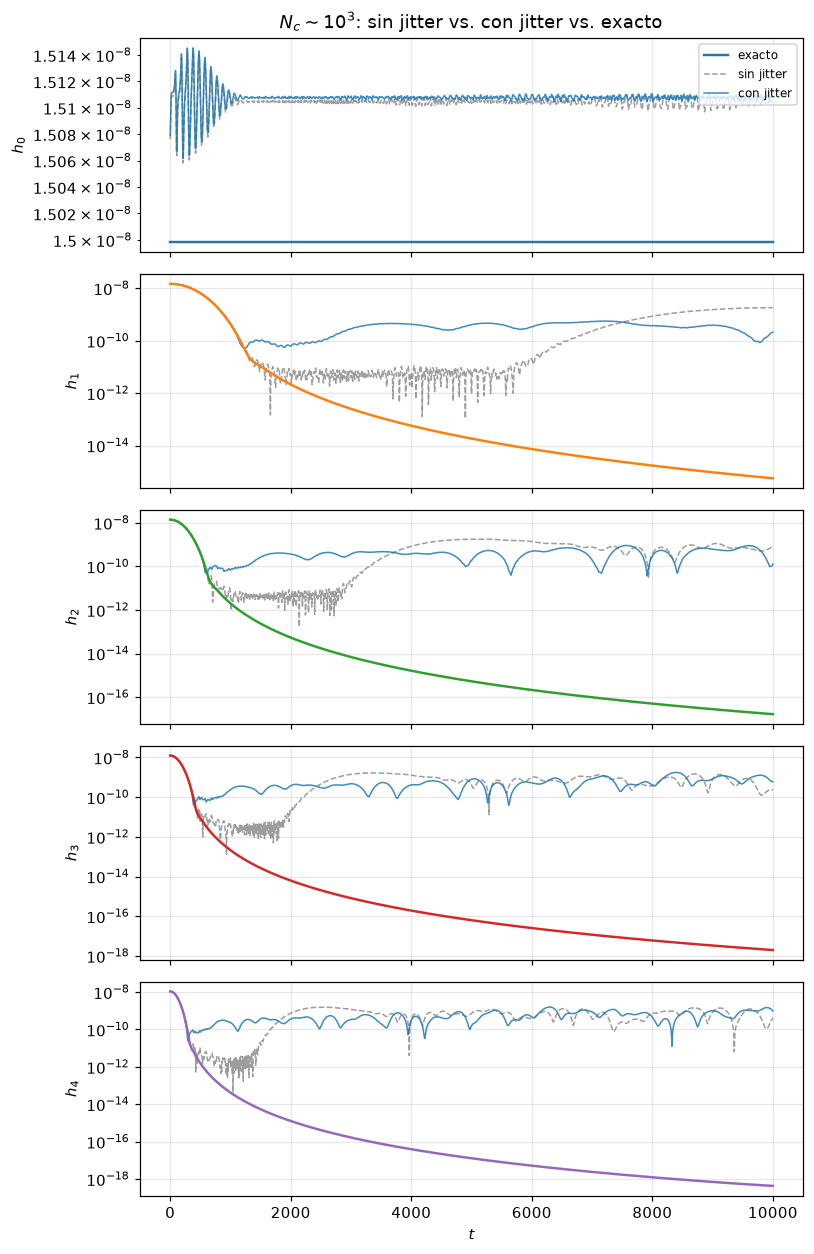

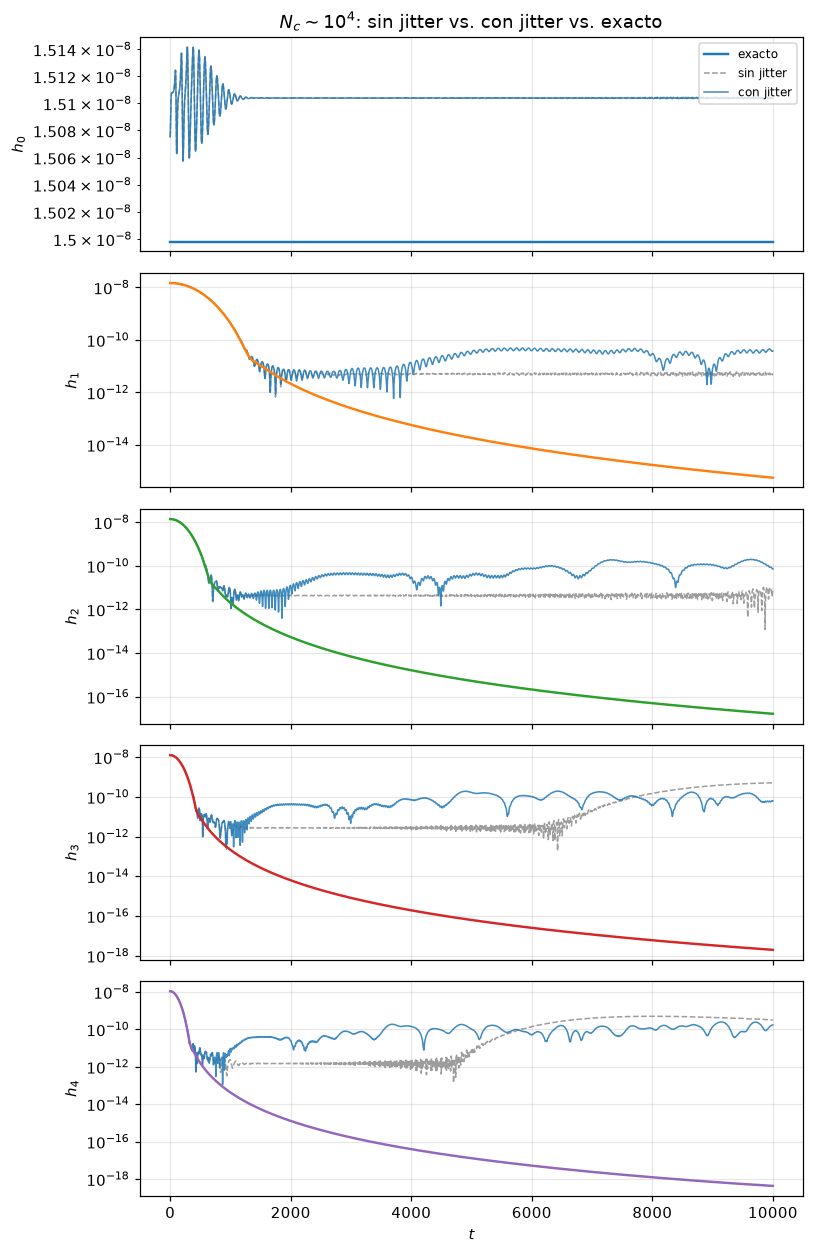

In [13]:

pairs = [("$N_c\\sim10^3$", "$N_c\\sim10^3$ jitter", "N~1e3"),
         ("$N_c\\sim10^4$", "$N_c\\sim10^4$ jitter", "N~1e4")]

for label_plain, label_jitter, tag in pairs:
    fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
    for ax, k in zip(axes, modes):
        ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
        ax.plot(sims[label_plain][:, 0], sims[label_plain][:, k+1], lw=1.0,
                 color="0.55", ls="--", alpha=0.85, label="sin jitter")
        ax.plot(sims_jitter[label_jitter][:, 0], sims_jitter[label_jitter][:, k+1], lw=1.0,
                 color="tab:blue", ls="-", alpha=0.85, label="con jitter")
        ax.set_yscale("log")
        ax.set_ylabel(f"$h_{k}$")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("$t$")
    axes[0].set_title(f"{label_plain}: sin jitter vs. con jitter vs. exacto")
    fig.tight_layout()
    fig.savefig(f"hk_jitter_{tag}.png", dpi=140)
    plt.show()



### Resumen numérico: media/σ en $t\in[8000,10000]$, sin vs. con jitter


In [14]:

print(f"{'':>6}{'sin jitter':>34}{'con jitter':>34}")
for label_plain, label_jitter, tag in pairs:
    print(f"\n-- {label_plain} --")
    for k in modes:
        d0 = sims[label_plain]; d1 = sims_jitter[label_jitter]
        m0 = d0[:, 0] >= 8000; m1 = d1[:, 0] >= 8000
        v0 = d0[m0, k+1]; v1 = d1[m1, k+1]
        print(f"h{k}:  {v0.mean():>12.3e} +/- {v0.std():>10.3e}      "
              f"{v1.mean():>12.3e} +/- {v1.std():>10.3e}")


                              sin jitter                        con jitter

-- $N_c\sim10^3$ --
h0:     1.510e-08 +/-  3.241e-12         1.511e-08 +/-  1.090e-12
h1:     1.464e-09 +/-  2.912e-10         2.882e-10 +/-  9.592e-11
h2:     6.990e-10 +/-  2.076e-10         5.139e-10 +/-  2.170e-10
h3:     7.282e-10 +/-  3.862e-10         9.425e-10 +/-  3.682e-10
h4:     8.192e-10 +/-  3.920e-10         7.035e-10 +/-  3.641e-10

-- $N_c\sim10^4$ --
h0:     1.510e-08 +/-  3.044e-13         1.510e-08 +/-  2.088e-13
h1:     5.071e-12 +/-  4.471e-13         2.616e-11 +/-  1.089e-11
h2:     4.737e-12 +/-  1.615e-12         1.083e-10 +/-  4.276e-11
h3:     3.497e-10 +/-  1.088e-10         8.704e-11 +/-  4.060e-11
h4:     4.260e-10 +/-  5.515e-11         1.364e-10 +/-  5.408e-11



## 8. Dos candidatos de seguimiento: secuencia 2D genuina (Halton) y jitter directo en $(Q_3,J_3)$

El jitter Weyl/Kronecker de la Sec. 7 no ayudó (y a $N_c\sim10^4$ fue
claramente peor). `BUGS_TODO.md` dejó anotados dos candidatos sin
evaluar, y esta sección los prueba, cada uno por separado, con los
mismos pares $N_c\sim10^3/10^4$:

- **`aa_halton`**: mismo lugar que el jitter anterior -- perturbar
  $(r,p_r)$ -- pero con una secuencia de Halton genuinamente 2D
  (bases 2 y 3 vía inversa radical) en vez de dos secuencias de Weyl
  1D acopladas por el mismo índice `indx`.
- **`aa_qj`**: rejilla construida directamente en $(Q_3,J_3)$ (donde
  vive la regularidad que causa la recurrencia), con el mismo jitter
  de Weyl original ahí, invertida a $(r,p_r)$ resolviendo
  $Q_r=\eta-e\sin\eta$ (ecuación tipo Kepler) con Newton-Raphson.
  El tamaño de grilla se recalibró (`Nrc=Npc=121` y `383` en vez de
  `240` y `760`) para que el número de partículas *después* del corte
  coincida con el baseline (1003 y 10099 vs. 1001 y 10072) -- si no,
  la comparación quedaría contaminada por tener ~4x más partículas.

Implementado en `vlasov-poisson_PIC/src/initial_data.f90` como
estados nuevos (`aa`, `aa_halton` y `aa_qj` conviven en el mismo
código, sin tocar el baseline).


In [15]:

sims_v2 = {}
for label, fname in [
    ("$N_c\\sim10^3$ halton", "hk1_N1e3_halton.tl"),
    ("$N_c\\sim10^4$ halton", "hk1_N1e4_halton.tl"),
    ("$N_c\\sim10^3$ qj",     "hk1_N1e3_qj.tl"),
    ("$N_c\\sim10^4$ qj",     "hk1_N1e4_qj.tl"),
]:
    path = os.path.join(data_dir, fname)
    if os.path.exists(path):
        sims_v2[label] = np.genfromtxt(path)
    else:
        print(f"(no encontrado: {path} -- salteado)")

for label, data in sims_v2.items():
    print(f"{label}: {data.shape[0]} filas, t de {data[0,0]:.0f} a {data[-1,0]:.0f}")


$N_c\sim10^3$ halton: 4001 filas, t de 0 a 10000
$N_c\sim10^4$ halton: 4001 filas, t de 0 a 10000
$N_c\sim10^3$ qj: 4001 filas, t de 0 a 10000
$N_c\sim10^4$ qj: 4001 filas, t de 0 a 10000


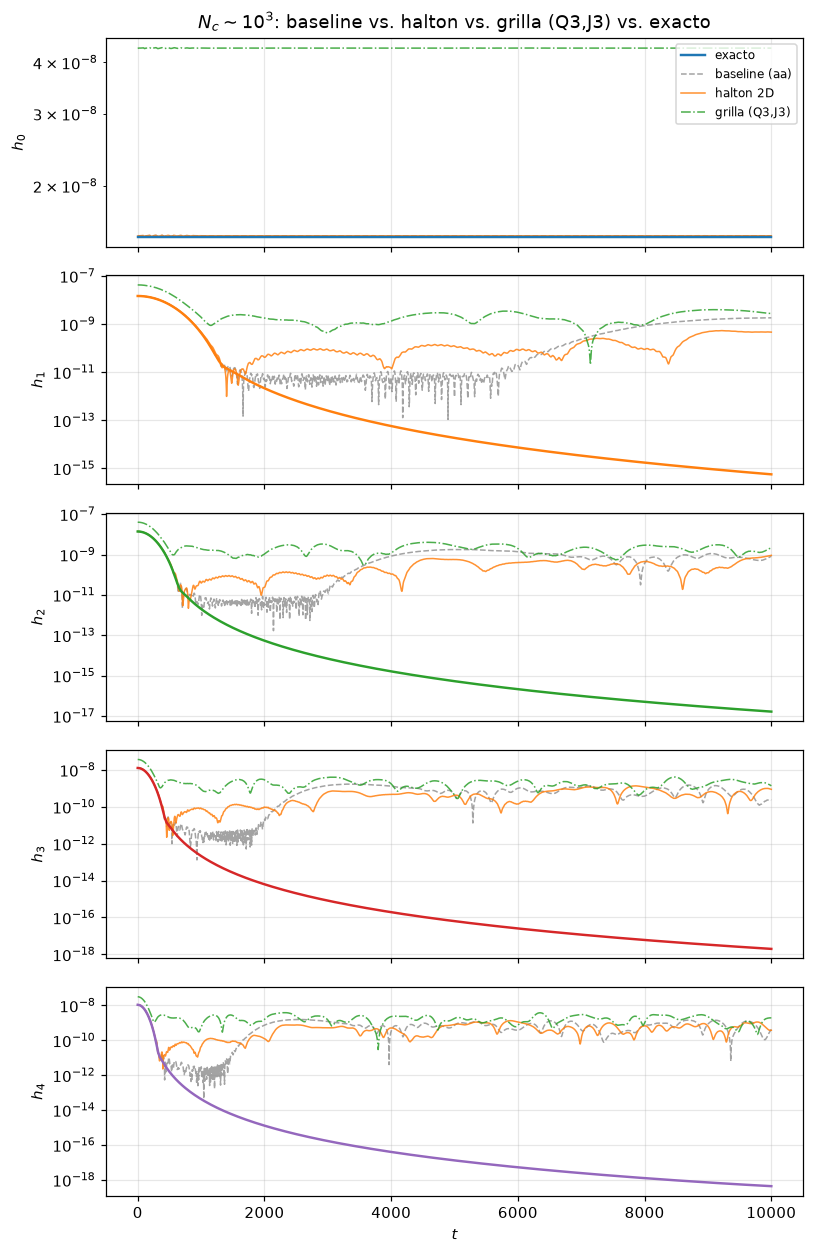

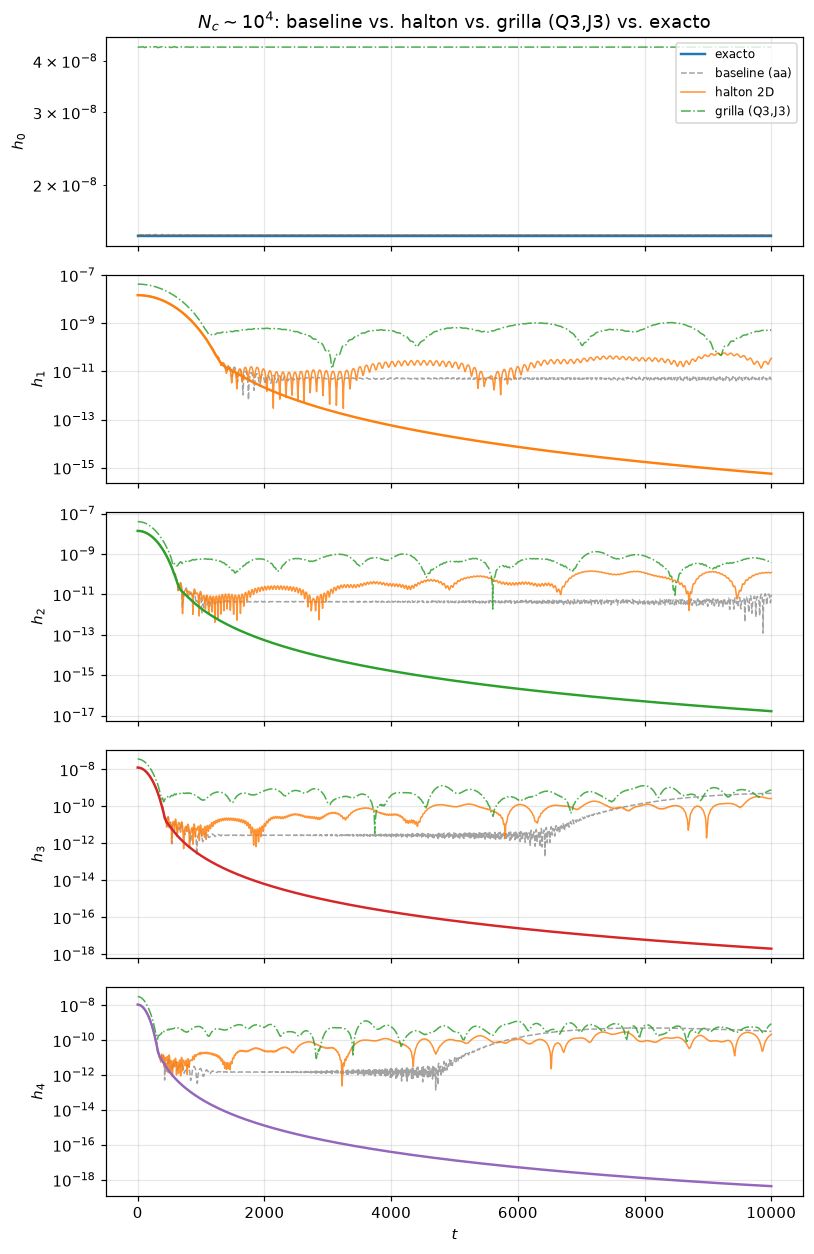

In [16]:

groups = [
    ("$N_c\\sim10^3$", "$N_c\\sim10^3$ halton", "$N_c\\sim10^3$ qj", "N~1e3"),
    ("$N_c\\sim10^4$", "$N_c\\sim10^4$ halton", "$N_c\\sim10^4$ qj", "N~1e4"),
]

for label_plain, label_halton, label_qj, tag in groups:
    fig, axes = plt.subplots(len(modes), 1, figsize=(7.5, 2.3*len(modes)), sharex=True)
    for ax, k in zip(axes, modes):
        ax.plot(t_array, hk_t[k], lw=1.6, color=f"C{k}", label="exacto", zorder=3)
        ax.plot(sims[label_plain][:, 0], sims[label_plain][:, k+1], lw=1.0,
                 color="0.55", ls="--", alpha=0.8, label="baseline (aa)")
        if label_halton in sims_v2:
            ax.plot(sims_v2[label_halton][:, 0], sims_v2[label_halton][:, k+1], lw=1.0,
                     color="tab:orange", ls="-", alpha=0.85, label="halton 2D")
        if label_qj in sims_v2:
            ax.plot(sims_v2[label_qj][:, 0], sims_v2[label_qj][:, k+1], lw=1.0,
                     color="tab:green", ls="-.", alpha=0.85, label="grilla (Q3,J3)")
        ax.set_yscale("log")
        ax.set_ylabel(f"$h_{k}$")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=8, loc="upper right")
    axes[-1].set_xlabel("$t$")
    axes[0].set_title(f"{label_plain}: baseline vs. halton vs. grilla (Q3,J3) vs. exacto")
    fig.tight_layout()
    fig.savefig(f"hk_v2_{tag}.png", dpi=140)
    plt.show()



### Resumen numérico: media/σ en $t\in[8000,10000]$


In [17]:

print(f"{'':>6}{'baseline (aa)':>26}{'halton 2D':>26}{'grilla (Q3,J3)':>26}")
for label_plain, label_halton, label_qj, tag in groups:
    print(f"\n-- {label_plain} --")
    for k in modes:
        d0 = sims[label_plain]
        m0 = d0[:, 0] >= 8000
        v0 = d0[m0, k+1]
        row = f"h{k}:  {v0.mean():>10.3e}+/-{v0.std():>9.3e}"
        for lab in (label_halton, label_qj):
            if lab in sims_v2:
                d1 = sims_v2[lab]
                m1 = d1[:, 0] >= 8000
                v1 = d1[m1, k+1]
                row += f"   {v1.mean():>10.3e}+/-{v1.std():>9.3e}"
            else:
                row += f"   {'--':>22}"
        print(row)


                   baseline (aa)                 halton 2D            grilla (Q3,J3)

-- $N_c\sim10^3$ --
h0:   1.510e-08+/-3.241e-12    1.511e-08+/-1.244e-12    4.335e-08+/-5.220e-12
h1:   1.464e-09+/-2.912e-10    3.373e-10+/-1.859e-10    3.152e-09+/-8.240e-10
h2:   6.990e-10+/-2.076e-10    3.447e-10+/-2.267e-10    2.022e-09+/-6.657e-10
h3:   7.282e-10+/-3.862e-10    5.556e-10+/-2.590e-10    2.039e-09+/-8.426e-10
h4:   8.192e-10+/-3.920e-10    6.093e-10+/-2.509e-10    1.653e-09+/-8.783e-10

-- $N_c\sim10^4$ --
h0:   1.510e-08+/-3.044e-13    1.510e-08+/-1.962e-13    4.323e-08+/-1.510e-12
h1:   5.071e-12+/-4.471e-13    3.466e-11+/-1.197e-11    5.329e-10+/-3.293e-10
h2:   4.737e-12+/-1.615e-12    7.280e-11+/-3.703e-11    3.591e-10+/-1.789e-10
h3:   3.497e-10+/-1.088e-10    1.329e-10+/-8.454e-11    6.370e-10+/-2.589e-10
h4:   4.260e-10+/-5.515e-11    1.212e-10+/-5.957e-11    4.275e-10+/-1.547e-10
